# UrbanPulse — Notebook 04: Model Comparison & Selection

Bible §5 Notebook 04. Logic in `compare.py`.

Selection: max **test ROC-AUC**, tiebreak precision@op, constraint inference < 500 ms/row. The operating threshold is the **F1-optimal point on the validation split** (never fit on test). Test metrics are then reported at that threshold.

**Produces:** `reports/model_comparison/*` + `models/best_model.pkl` + `models/best_model_meta.json`.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import compare, config
import pandas as pd

## 1. Run comparison (loads the 7 trained models)
Requires `python train.py` to have produced `models/*.pkl`.

In [2]:
out = compare.run()
out['table']

,model,roc_auc,pr_auc,op_threshold,precision@op,recall@op,f1@op,train_time_s,infer_ms_per_row
0,catboost,0.9770,0.8574,0.423,0.7281,0.8390,0.7796,15.75,0.0005
1,xgboost,0.9764,0.8543,0.418,0.7244,0.8392,0.7776,5.33,0.0052
2,lightgbm,0.9762,0.8480,0.416,0.7238,0.8384,0.7769,5.00,0.0077
3,random_forest,0.9759,0.8510,0.332,0.6971,0.8660,0.7725,61.73,0.0095
4,gradient_boosting,0.9752,0.8472,0.382,0.7130,0.8454,0.7736,73.93,0.0007
5,extra_trees,0.9751,0.8478,0.362,0.7068,0.8549,0.7738,12.05,0.0095
6,decision_tree,0.9482,0.7552,0.286,0.6940,0.8308,0.7562,2.69,0.0001


## 2. Winner + operating point

In [3]:
print(json.dumps(out['meta'], indent=2))

{
  "best_model": "catboost",
  "operating_threshold": 0.4227929085894968,
  "horizon_intervals": 3,
  "test_metrics_at_op": {
    "roc_auc": 0.977,
    "pr_auc": 0.8574,
    "precision@op": 0.7281,
    "recall@op": 0.839,
    "f1@op": 0.7796
  }
}


## 3. Figures (saved to reports/model_comparison/)
ROC-AUC bar · ROC curves · PR curves · confusion (top 3) · efficiency frontier · feature importances.

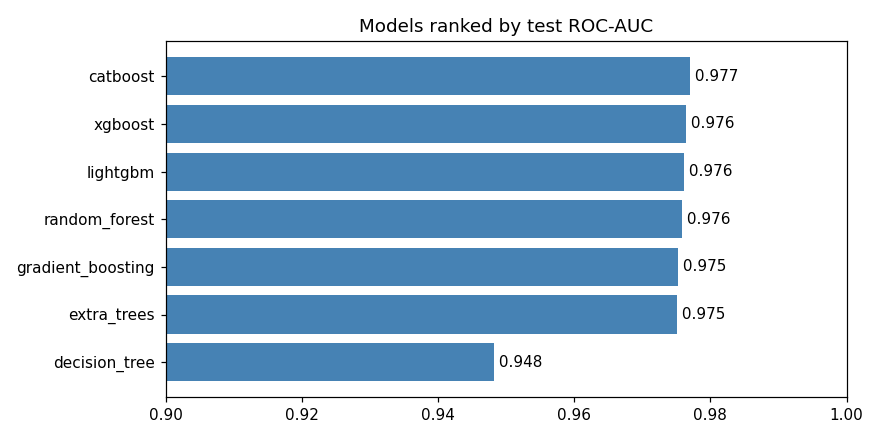

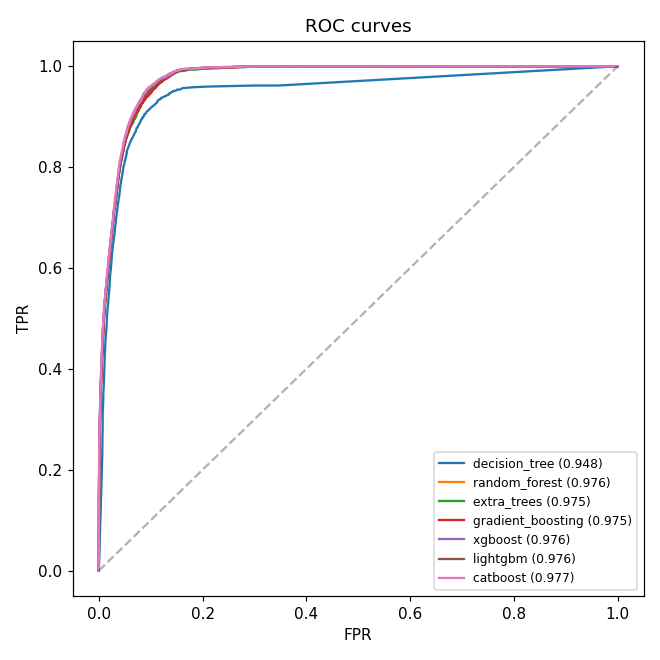

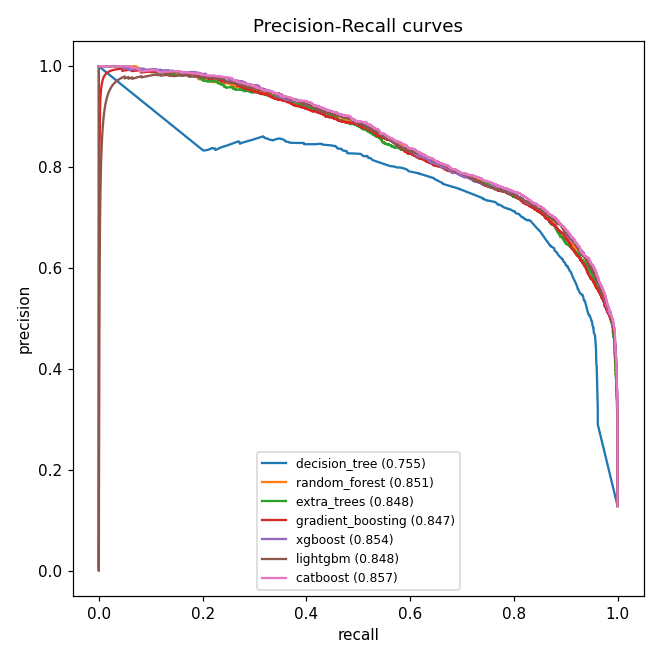

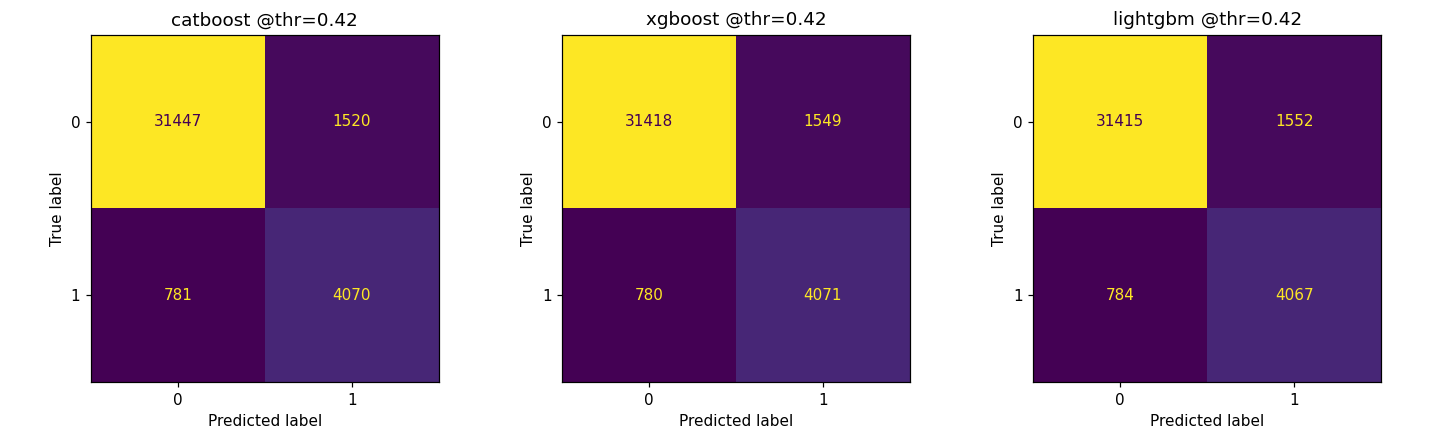

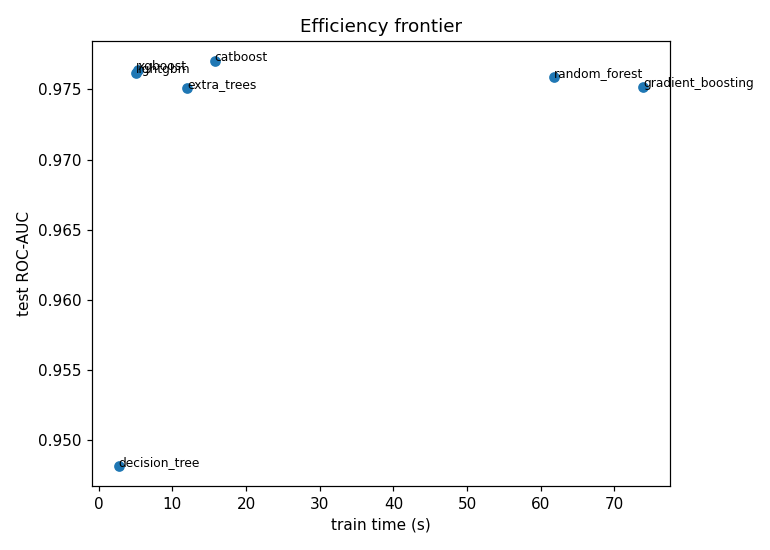

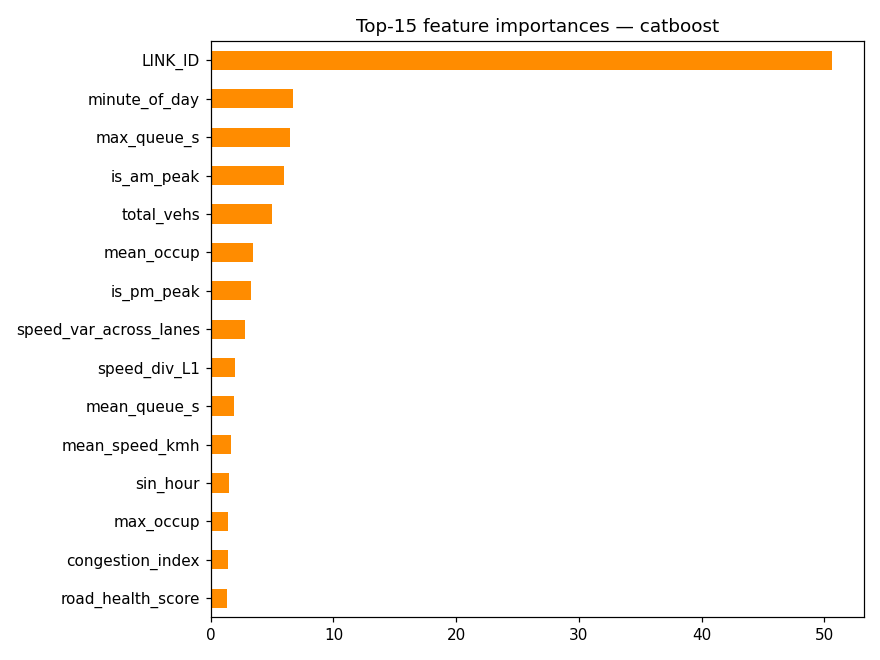

In [4]:
from IPython.display import Image, display
for f in ['roc_auc_bar','roc_curves','pr_curves','confusion_top3','efficiency_frontier','feature_importance_best']:
    p = config.REPORTS_DIR/'model_comparison'/f'{f}.png'
    if p.exists(): display(Image(str(p)))

## 4. Gate

In [5]:
t=out['table']
print('best ROC-AUC > 0.85:', bool(t.roc_auc.max()>0.85))
print('all infer < 500ms/row:', bool((t.infer_ms_per_row<500).all()))

best ROC-AUC > 0.85: True
all infer < 500ms/row: True
